In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/forecasted_rent_mortgage.csv')
df.head()

,RegionID,RegionName,StateName,Date,ForecastedRentValue,ForecastedMortgageValue
0,394304,"Akron, OH",OH,2018-05-31,841.759436,579.064519
1,394304,"Akron, OH",OH,2018-06-30,844.636075,579.608568
2,394304,"Akron, OH",OH,2018-07-31,844.669409,577.137368
3,394304,"Akron, OH",OH,2018-08-31,847.019153,580.914277
4,394304,"Akron, OH",OH,2018-09-30,851.171453,588.849924


In [ ]:
df["Rent_to_Mortgage_Ratio"] = df["ForecastedRentValue"] / df["ForecastedMortgageValue"]
df["Monthly_Savings_or_Cost"] = df["ForecastedMortgageValue"] - df["ForecastedRentValue"]

In [ ]:
df["Affordability_Index"] = df["ForecastedMortgageValue"] / (df["ForecastedRentValue"] + df["ForecastedMortgageValue"])

In [ ]:
# Average by region
region_summary = (
    df.groupby(["RegionName", "StateName"])
      .agg({
          "ForecastedRentValue": "mean",
          "ForecastedMortgageValue": "mean",
          "Rent_to_Mortgage_Ratio": "mean"
      })
      .reset_index()
      .sort_values("Rent_to_Mortgage_Ratio", ascending=False)
)
region_summary.head()

,RegionName,StateName,ForecastedRentValue,ForecastedMortgageValue,Rent_to_Mortgage_Ratio
29,"El Paso, TX",TX,1409.437181,951.498125,1.573035
81,"Syracuse, NY",NY,1516.255283,1039.377380,1.546894
47,"McAllen, TX",TX,1090.644544,790.903944,1.493396
64,"Pittsburgh, PA",PA,1428.688457,995.837556,1.486783
17,"Chicago, IL",IL,2093.248694,1464.338248,1.476780


In [ ]:
df["Buy_Rent_Index"] = np.where(
    (df["Rent_to_Mortgage_Ratio"] > 1.1),
    "Buy",
    np.where(df["Rent_to_Mortgage_Ratio"] < 0.9, "Rent", "Neutral")
)

In [ ]:
df

,RegionID,RegionName,StateName,Date,ForecastedRentValue,ForecastedMortgageValue,Rent_to_Mortgage_Ratio,Monthly_Savings_or_Cost,Affordability_Index,Buy_Rent_Index
0,394304,"Akron, OH",OH,2018-05-31,841.759436,579.064519,1.453654,-262.694917,0.407555,Buy
1,394304,"Akron, OH",OH,2018-06-30,844.636075,579.608568,1.457253,-265.027506,0.406959,Buy
2,394304,"Akron, OH",OH,2018-07-31,844.669409,577.137368,1.463550,-267.532041,0.405918,Buy
3,394304,"Akron, OH",OH,2018-08-31,847.019153,580.914277,1.458079,-266.104876,0.406822,Buy
4,394304,"Akron, OH",OH,2018-09-30,851.171453,588.849924,1.445481,-262.321528,0.408917,Buy
...,...,...,...,...,...,...,...,...,...,...
13887,753924,"Urban Honolulu, HI",HI,2030-07-31,3500.366834,4342.141981,0.806138,841.775147,0.553667,Rent
13888,753924,"Urban Honolulu, HI",HI,2030-08-31,3510.199161,4342.245287,0.808383,832.046126,0.552980,Rent
13889,753924,"Urban Honolulu, HI",HI,2030-09-30,3522.247325,4346.853270,0.810298,824.605945,0.552395,Rent
13890,753924,"Urban Honolulu, HI",HI,2030-10-31,3533.946709,4345.918820,0.813164,811.972111,0.551522,Rent


In [ ]:
decision_summary = df.groupby("StateName")["Buy_Rent_Index"].value_counts(normalize=True).unstack().fillna(0)
decision_summary

Buy_Rent_Index,Buy,Neutral,Rent
StateName,,,
AL,0.748344,0.251656,0.000000
AR,0.688742,0.311258,0.000000
AZ,0.268212,0.195364,0.536424
CA,0.147682,0.286755,0.565563
CO,0.068433,0.207506,0.724062
CT,0.514349,0.390728,0.094923
FL,0.653974,0.325331,0.020695
GA,0.331126,0.602649,0.066225
HI,0.000000,0.192053,0.807947


Text(0.5, 1.0, 'Overall Rent vs Buy Decision Distribution')

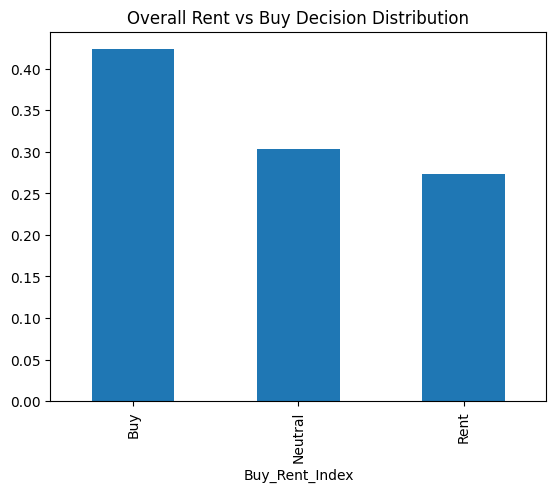

In [ ]:
decision_summary[['Buy','Neutral','Rent']].mean().plot(kind='bar')
plt.title('Overall Rent vs Buy Decision Distribution')

In [ ]:
state_name_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}

state_centroids = {
    'AL': (32.7794, -86.8287), 'AK': (64.0685, -152.2782), 'AZ': (34.2744, -111.6602),
    'AR': (34.8938, -92.4426), 'CA': (37.1841, -119.4696), 'CO': (38.9972, -105.5478),
    'CT': (41.6219, -72.7273), 'DE': (38.9896, -75.5050), 'FL': (28.6305, -82.4497),
    'GA': (32.6415, -83.4426), 'HI': (20.2927, -156.3737), 'ID': (44.3509, -114.6130),
    'IL': (40.0417, -89.1965), 'IN': (39.8942, -86.2816), 'IA': (42.0751, -93.4960),
    'KS': (38.4937, -98.3804), 'KY': (37.5347, -85.3021), 'LA': (30.8710, -91.9680),
    'ME': (45.3695, -69.2428), 'MD': (39.0550, -76.7909), 'MA': (42.2596, -71.8083),
    'MI': (44.3467, -85.4102), 'MN': (46.2807, -94.3053), 'MS': (32.7364, -89.6678),
    'MO': (38.3566, -92.4580), 'MT': (47.0527, -109.6333), 'NE': (41.5378, -99.7951),
    'NV': (39.3289, -116.6312), 'NH': (43.6805, -71.5811), 'NJ': (40.1907, -74.6728),
    'NM': (34.4071, -106.1126), 'NY': (42.9538, -75.5268), 'NC': (35.5557, -79.3877),
    'ND': (47.4501, -100.4659), 'OH': (40.2862, -82.7937), 'OK': (35.5889, -97.4943),
    'OR': (43.9336, -120.5583), 'PA': (40.8781, -77.7996), 'RI': (41.6762, -71.5562),
    'SC': (33.9169, -80.8964), 'SD': (44.4443, -100.2263), 'TN': (35.8580, -86.3505),
    'TX': (31.4757, -99.3312), 'UT': (39.3055, -111.6703), 'VT': (44.0687, -72.6658),
    'VA': (37.5215, -78.8537), 'WA': (47.3826, -120.4472), 'WV': (38.6409, -80.6227),
    'WI': (44.6243, -89.9941), 'WY': (42.9957, -107.5512)
}

decision_summary_reset = decision_summary.reset_index()
decision_summary_reset['StateNameFull'] = decision_summary_reset['StateName'].map(state_name_map)
decision_summary_reset['lat'] = decision_summary_reset['StateName'].map(lambda x: state_centroids.get(x, (np.nan, np.nan))[0])
decision_summary_reset['lon'] = decision_summary_reset['StateName'].map(lambda x: state_centroids.get(x, (np.nan, np.nan))[1])
decision_summary_reset['Dominant_Category'] = decision_summary_reset[['Buy', 'Neutral', 'Rent']].idxmax(axis=1)
decision_summary_reset['Dominant_Value'] = decision_summary_reset.apply(lambda row: row[row['Dominant_Category']], axis=1)
decision_summary_reset['Custom_Hover_Text'] = (
    decision_summary_reset['Dominant_Category'] + ' Favorability: ' +
    decision_summary_reset['Dominant_Value'].round(3).astype(str)
)

In [ ]:
fig = px.choropleth(
    decision_summary_reset,
    locations='StateName',
    locationmode='USA-states',
    color='Buy',
    scope='usa',
    color_continuous_scale=[
        (0, "#d73027"), (0.3, "#fdae61"), (0.5, "#ffffbf"),
        (0.7, "#a6d96a"), (1, "#1a9850")
    ],
    title='Buy vs Rent Favorability Across U.S. States',
    hover_name='StateName',
    custom_data=['Custom_Hover_Text']
)

fig.add_trace(
    go.Scattergeo(
        locationmode='USA-states',
        locations=decision_summary_reset['StateName'],
        lat=decision_summary_reset['lat'],
        lon=decision_summary_reset['lon'],
        mode='text',
        text=decision_summary_reset['StateName'],
        textfont=dict(
            size=8,
            color="black"
        ),
        showlegend=False,
        hoverinfo='skip'
    )
)

fig.update_layout(
    title=dict(
        text='Buy vs Rent Favorability Across U.S. States (Green = Buy, Red = Rent)',
        x=0.5
    ),
    coloraxis_colorbar=dict(
        title="Favorability Index",
        tickvals=[0, 0.5, 1],
        ticktext=["Rent Favorable", "Neutral", "Buy Favorable"]
    )
)

fig.update_geos(
    lakecolor='rgb(255, 255, 255)',
    landcolor='rgb(243, 243, 243)',
    projection_type="albers usa"
)

fig.update_traces(
    selector=dict(type='choropleth'),
    hovertemplate="<b>%{hovertext}</b><br><br>%{customdata[0]}<extra></extra>"
)

fig.show()